In [12]:
import os, re, time, torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score
import warnings
warnings.filterwarnings('ignore')

ROOT = r"D:\Python\HSE_CS_AI25_Project\MURA-v1.1\MURA-enhanced"
torch.backends.cudnn.benchmark = True

In [2]:
class C3(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(1, 32, 3, padding=1)
        self.c2 = nn.Conv2d(32, 64, 3, padding=1)
        self.c3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, 1)
    def forward(self, x):
        x = self.pool(F.relu(self.c1(x)))
        x = self.pool(F.relu(self.c2(x)))
        x = self.pool(F.relu(self.c3(x)))
        x = self.avg(x)
        return self.fc(x.view(x.size(0), -1))

class C5(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.2),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(256, 1)
    def forward(self, x):
        return self.fc(self.seq(x).view(x.size(0), -1))

class C5Res(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.c2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # 🛠 Исправление: Проекция для skip-connection
        # skip_in имеет размер [B, 64, 56, 56], а x после 2 пулингов будет [B, 128, 14, 14]
        # Нужно уменьшить 56->14 и 64->128
        self.shortcut = nn.Sequential(
            nn.AvgPool2d(kernel_size=4, stride=4),
            nn.Conv2d(64, 128, kernel_size=1)
        )

        self.c3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.c4 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.c5 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout(0.2)
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, 1)
        
    def forward(self, x):
        x = self.pool(self.drop(F.relu(self.bn1(self.c1(x)))))
        x = self.pool(self.drop(F.relu(self.bn2(self.c2(x)))))
        skip_in = x
        
        x = self.pool(self.drop(F.relu(self.bn3(self.c3(x)))))
        x = self.pool(self.drop(F.relu(self.bn4(self.c4(x)))))
        
        # Складываем x с преобразованным skip_in
        x = F.relu(x + self.shortcut(skip_in))
        
        x = self.avg(F.relu(self.bn5(self.c5(x))))
        return self.fc(x.view(x.size(0), -1))

In [3]:
class MDSet(Dataset):
    def __init__(self, f_paths, f_lbls, tfm):
        self.ps, self.ls, self.tfm = f_paths, f_lbls, tfm
    def __len__(self): return len(self.ps)
    def __getitem__(self, i):
        img = Image.open(self.ps[i]).convert('L')
        return self.tfm(img), torch.tensor(self.ls[i], dtype=torch.float32)

def get_data(root, split='train'):
    pths, lbls = [], []
    base = os.path.join(root, split)
    for dp, _, fns in os.walk(base):
        for f in fns:
            if f.endswith(('.png','.jpg','.jpeg')):
                pths.append(os.path.join(dp, f))
                lbls.append(1 if 'positive' in dp else 0)
    return pths, lbls

def get_study_id(p):
    # Надежный поиск patient/study через Regex
    p = p.replace('\\', '/')
    match = re.search(r'(patient\d+)/(study\d+[^/]*)', p)
    if match:
        return f"{match.group(1)}_{match.group(2)}"
    parts = p.split('/')
    return f"{parts[-3]}_{parts[-2]}"

def get_loaders(bs=256):
    tr_tfm = transforms.Compose([transforms.Resize((224,224)), transforms.RandomHorizontalFlip(), 
                                 transforms.RandomRotation(10), transforms.ToTensor()])
    va_tfm = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
    tr_p, tr_l = get_data(ROOT, 'train')
    va_p, va_l = get_data(ROOT, 'valid')
    
    # pin_memory=True нужен для non_blocking=True в цикле обучения
    tr_dl = DataLoader(MDSet(tr_p, tr_l, tr_tfm), bs, shuffle=True, num_workers=0, pin_memory=True)
    va_dl = DataLoader(MDSet(va_p, va_l, va_tfm), bs, num_workers=0, pin_memory=True)
    return tr_dl, va_dl, va_p, va_l

In [4]:
def tune_threshold(paths, lbls, probs, thr_range=np.arange(0.30, 0.71, 0.01)):
    studies = {}
    for p, l, pr in zip(paths, lbls, probs):
        st = get_study_id(p)
        if st not in studies: studies[st] = {'l': [], 'p': []}
        studies[st]['l'].append(l)
        studies[st]['p'].append(pr)
    s_l = np.array([np.mean(v['l']) for v in studies.values()])
    s_p = np.array([np.mean(v['p']) for v in studies.values()])
    best_k, best_thr = -1, 0.5
    for t in thr_range:
        k = cohen_kappa_score((s_l > 0.5).astype(int), (s_p > t).astype(int))
        if k > best_k: best_k, best_thr = k, t
    return best_thr, best_k

In [5]:
def run_model(mdl_name, mdl_cls, ep=15, bs=256, lr=3e-4):
    dev = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Using: {dev} | Model: {mdl_name} | LR: {lr}')
    tr_dl, va_dl, va_p, va_l = get_loaders(bs)
    mdl = mdl_cls().to(dev)
    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.457]).to(dev))
    opt = optim.Adam(mdl.parameters(), lr=lr)
    scaler = torch.amp.GradScaler(device='cuda') # Скейлер для AMP
    best_k, best_thr = -1, 0.5
    t0 = time.time()
    
    for e in range(ep):
        mdl.train()
        t_loss = 0
        for x, y in tr_dl:
            # non_blocking=True ускоряет трансфер, если pin_memory=True
            x, y = x.to(dev, non_blocking=True), y.to(dev, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            
            # AMP: вычисления в смешанной точности
            with torch.amp.autocast(device_type='cuda'):
                out = mdl(x).squeeze()
                loss = crit(out, y)
            
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            t_loss += loss.item()
            
        mdl.eval()
        v_preds, v_lbls = [], []
        # inference_mode быстрее и экономит память
        with torch.inference_mode():
            for x, y in va_dl:
                with torch.amp.autocast(device_type='cuda'):
                    out = torch.sigmoid(mdl(x.to(dev, non_blocking=True))).squeeze()
                v_preds.append(out.cpu().numpy())
                v_lbls.append(y.numpy())
        v_preds = np.concatenate(v_preds)
        v_lbls = np.concatenate(v_lbls)
        thr, k_st = tune_threshold(va_p, v_lbls, v_preds)
        if k_st > best_k: best_k, best_thr = k_st, thr
        
    fit_time = time.time() - t0
    k_img = cohen_kappa_score((v_lbls > 0.5).astype(int), (v_preds > best_thr).astype(int))
    print(f'Done. Best study_kappa: {best_k:.4f} | img_kappa: {k_img:.4f} | thr: {best_thr:.2f} | time: {fit_time:.1f}s')
    
    res = {'model_name': mdl_name, 'fit_time_seconds': fit_time, 'best_study_kappa': best_k, 'best_img_kappa': k_img, 'best_threshold': best_thr}
    return res, mdl # Возвращаем и метрики, и обученную модель

In [6]:
models_config = [('C3', C3), ('C5', C5), ('C5Res', C5Res)]
total_results = []
trained_models = {} # Словарь для хранения обученных моделей

for name, cls in models_config:
    res, model = run_model(name, cls, ep=15, bs=256, lr=3e-4)
    total_results.append(res)
    trained_models[name] = model
    torch.cuda.empty_cache()

total_results_df = pd.DataFrame(total_results)
display(total_results_df)

Using: cuda | Model: C3 | LR: 0.0003
Done. Best study_kappa: 0.2250 | img_kappa: 0.1987 | thr: 0.55 | time: 1512.2s
Using: cuda | Model: C5 | LR: 0.0003
Done. Best study_kappa: 0.5032 | img_kappa: 0.1983 | thr: 0.52 | time: 1787.7s
Using: cuda | Model: C5Res | LR: 0.0003
Done. Best study_kappa: 0.3468 | img_kappa: 0.2506 | thr: 0.43 | time: 1820.8s


,model_name,fit_time_seconds,best_study_kappa,best_img_kappa,best_threshold
0,C3,1512.160529,0.224960,0.198653,0.55
1,C5,1787.707719,0.503210,0.198260,0.52
2,C5Res,1820.826379,0.346784,0.250568,0.43


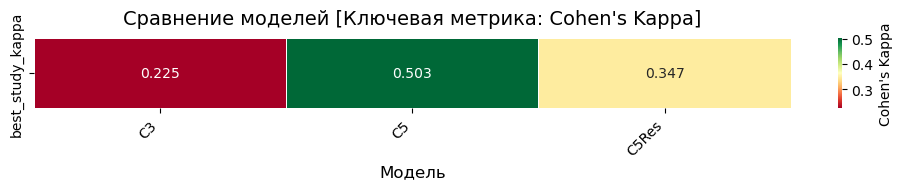

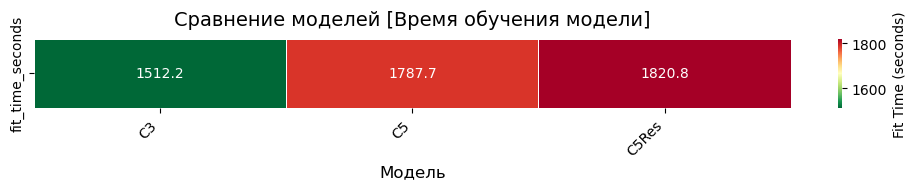

In [7]:
def show_heatmap_by_results(df, values_for_pivot, description, heatmap_params={}, figsize=(12, 3)):
    pivot = df.set_index('model_name')[[values_for_pivot]].T
    default_params = {'annot': True, 'fmt': ".3f", 'cmap': "RdYlGn", 'linewidths': 0.5, 'square': False}
    default_params.update(heatmap_params)
    
    plt.figure(figsize=figsize)
    ax = sns.heatmap(pivot, **default_params)
    plt.title(f"Сравнение моделей {description}", fontsize=14, pad=10)
    plt.xlabel("Модель", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

show_heatmap_by_results(total_results_df, 'best_study_kappa', "[Ключевая метрика: Cohen's Kappa]", {'cbar_kws': {'label': 'Cohen\'s Kappa'}, 'cmap': 'RdYlGn'}, figsize=(10, 2))
show_heatmap_by_results(total_results_df, 'fit_time_seconds', "[Время обучения модели]", {'cbar_kws': {'label': 'Fit Time (seconds)'}, 'fmt': ".1f", 'cmap': "RdYlGn_r"}, figsize=(10, 2))

In [15]:
def calculate_anatomy_metrics_with_threshold(va_paths, va_labels, va_probs, study_id_func):

    anatomies = ['XR_ELBOW', 'XR_FINGER', 'XR_FOREARM', 'XR_HAND', 
                 'XR_HUMERUS', 'XR_SHOULDER', 'XR_WRIST']
    results = {}
    
    for anat in anatomies:
        mask = [get_anatomy_from_path(p) == anat for p in va_paths]
        if not any(mask): continue
            
        anat_paths = [p for p, m in zip(va_paths, mask) if m]
        anat_labels = [l for l, m in zip(va_labels, mask) if m]
        anat_probs = [pr for pr, m in zip(va_probs, mask) if m]
        
        # Агрегация на уровень study
        studies = defaultdict(lambda: {'l': [], 'p': []})
        for p, l, pr in zip(anat_paths, anat_labels, anat_probs):
            st = study_id_func(p)
            studies[st]['l'].append(l)
            studies[st]['p'].append(pr)
        
        s_l = np.array([np.mean(v['l']) for v in studies.values()])
        s_p = np.array([np.mean(v['p']) for v in studies.values()])
        
        best_thr, best_k = tune_threshold(anat_paths, anat_labels, anat_probs)
        
        results[anat] = {
            'kappa': best_k,
            'threshold': best_thr,
            'n_studies': len(studies)
        }
        
    return results

In [16]:
anatomy_results = {}

_, _, va_p, va_l = get_loaders(bs=64)

print("Оценка моделей по анатомиям (с адаптивным порогом)...")

for name, mdl in trained_models.items():
    mdl.eval()
    dev = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Инференс
    v_preds, v_lbls = [], []
    with torch.inference_mode():
        va_tfm = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
        temp_ds = MDSet(va_p, va_l, va_tfm)
        temp_dl = DataLoader(temp_ds, batch_size=64, shuffle=False, num_workers=0)
        
        for x, y in temp_dl:
            out = torch.sigmoid(mdl(x.to(dev))).squeeze()
            v_preds.append(out.cpu().numpy())
            v_lbls.append(y.numpy())
            
    v_preds = np.concatenate(v_preds)
    v_lbls = np.concatenate(v_lbls)
    
    anat_metrics = calculate_anatomy_metrics_with_threshold(va_p, v_lbls, v_preds, get_study_id)
    anatomy_results[name] = anat_metrics
    
    _, overall_k = tune_threshold(va_p, v_lbls, v_preds)
    print(f"{name}: Best Overall Kappa (Adaptive) = {overall_k:.4f}")

torch.cuda.empty_cache()

Оценка моделей по анатомиям (с адаптивным порогом)...
C3: Best Overall Kappa (Adaptive) = 0.2250
C5: Best Overall Kappa (Adaptive) = 0.3919
C5Res: Best Overall Kappa (Adaptive) = 0.2838


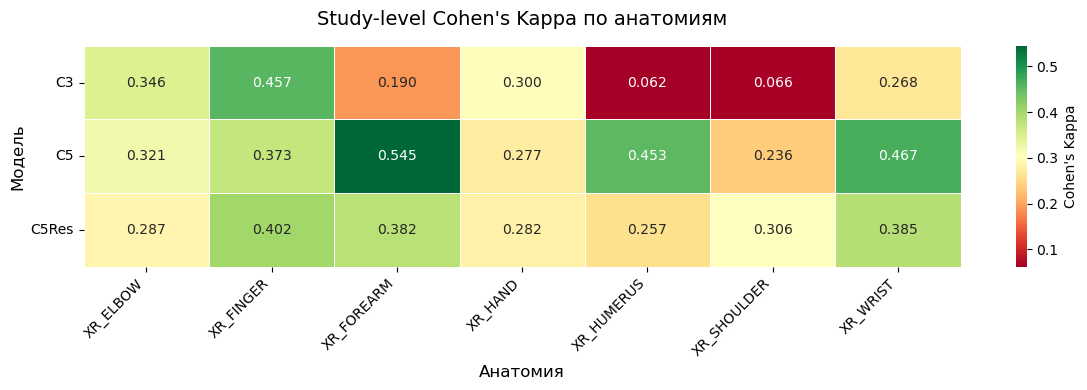

In [17]:
def plot_anatomy_kappa_heatmap(anatomy_results, figsize=(12, 4)):
    anatomies = ['XR_ELBOW', 'XR_FINGER', 'XR_FOREARM', 'XR_HAND', 
                 'XR_HUMERUS', 'XR_SHOULDER', 'XR_WRIST']
    models = list(anatomy_results.keys())
    
    data = []
    for anat in anatomies:
        row = {'Anatomy': anat}
        for model in models:
            if anat in anatomy_results[model]:
                row[model] = anatomy_results[model][anat]['kappa']
            else:
                row[model] = np.nan
        data.append(row)
        
    df = pd.DataFrame(data).set_index('Anatomy')
    
    plt.figure(figsize=figsize)
    sns.heatmap(df.T, annot=True, fmt='.3f', cmap='RdYlGn', 
                linewidths=0.5, cbar_kws={'label': "Cohen's Kappa"})
    
    plt.title('Study-level Cohen\'s Kappa по анатомиям', fontsize=14, pad=15)
    plt.xlabel('Анатомия', fontsize=12)
    plt.ylabel('Модель', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return df

anatomy_df = plot_anatomy_kappa_heatmap(anatomy_results)